<a href="https://colab.research.google.com/github/Layal06-gh/IT326-Airline-Satisfaction/blob/main/phases/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1-Data Analysis

## 1- Statistic summary:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://github.com/Layal06-gh/IT326-Airline-Satisfaction/raw/refs/heads/main/Dataset/Raw_dataset.csv')

df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


The statistical summary provides an overview of the Airline Passenger Satisfaction dataset, including mean, standard deviation, minimum, quartiles, and maximum values for numeric attributes (e.g., Age, Flight Distance, Departure Delay in Minutes, and Arrival Delay in Minutes). This summary helps us understand the data scale, detect extreme values in delay times, and identify features that require normalization or cleaning during preprocessing.

## 2. Missing Values Analysis


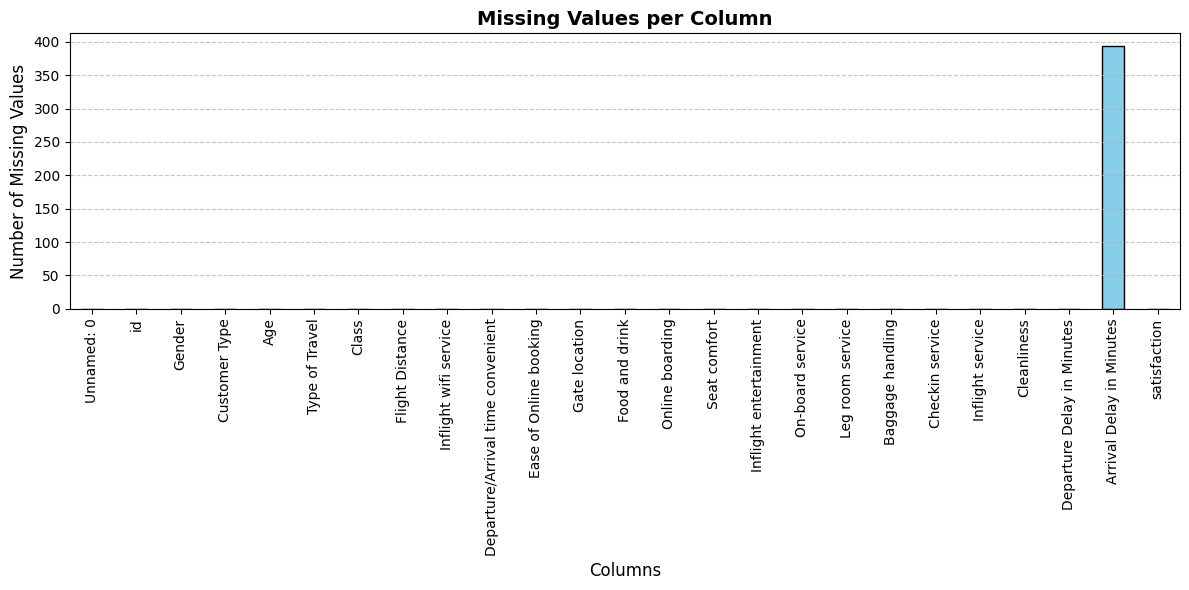

In [2]:
import matplotlib.pyplot as plt

missing_vals = df.isnull().sum()

plt.figure(figsize=(12, 6))
missing_vals.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The missing values analysis reveals that the dataset is clean and complete across almost all attributes, except for 'Arrival Delay in Minutes', which contains exactly 393 missing values.

Identifying these missing values directly justifies the necessity of applying an imputation technique (such as median imputation or mean imputation) during the Data Preprocessing stage to handle these 393 missing records before training classification models.


## 3. Boxplots

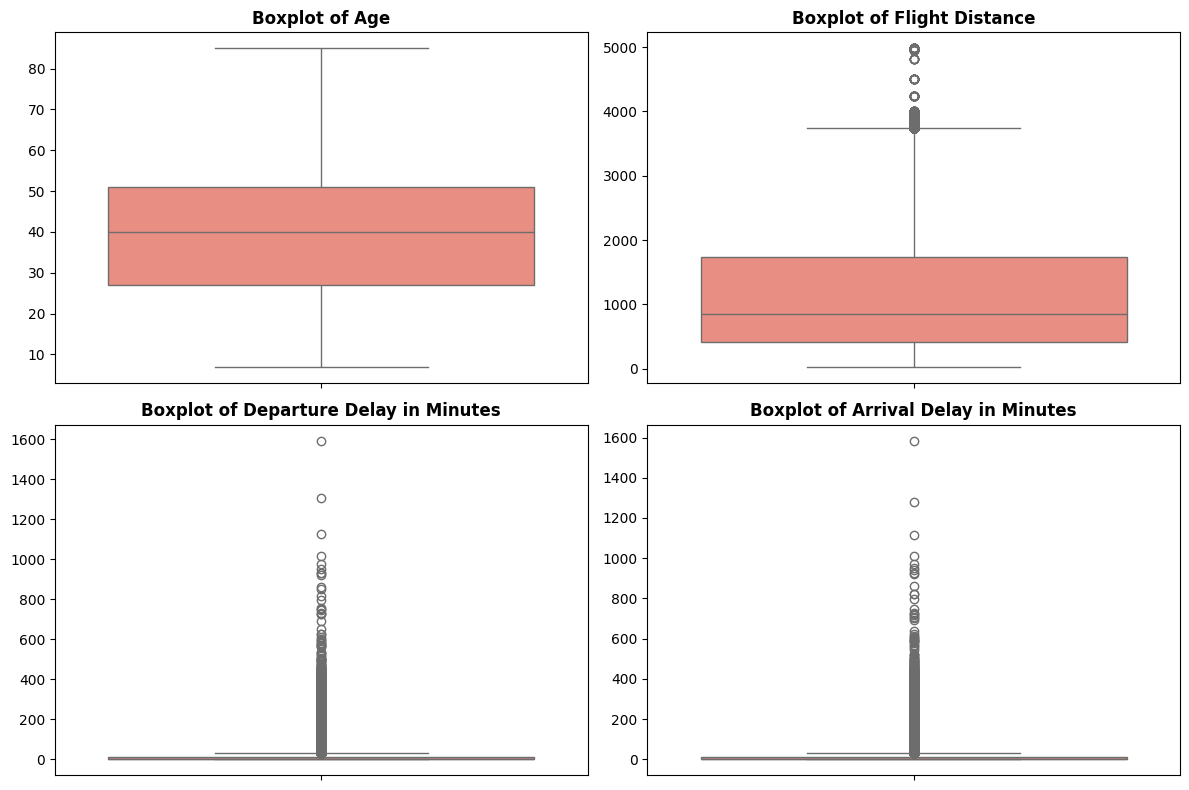

In [3]:
main_numeric_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize=(12, 8))
for i, col in enumerate(main_numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Outlier Analysis

The boxplot analysis across key numeric features reveals the following insights:

- **Departure Delay & Arrival Delay in Minutes:** Display a heavy concentration of severe upper outliers (reaching up to about 1,600 minutes). The box is extremely compressed near zero because more than half of the flights (about 56%) have no delay at all, so the first quartile (Q1) and the median are both 0 minutes, while the third quartile (Q3) is only 12 minutes for departure delay and 13 minutes for arrival delay. Consequently, any delay longer than about half an hour appears as an upper outlier.
- **Flight Distance:** Exhibits upper outliers for long-haul flight routes above approximately 3,740 miles (the upper whisker limit, Q3 + 1.5 × IQR), while maintaining a well-defined interquartile box for typical short/medium-haul flights.
- **Age:** Shows a clean, symmetric profile without any outliers.

## 4. Class Label Distribution

Number of classes: 2
                         Count  Percentage (%)
satisfaction                                  
neutral or dissatisfied  73452           56.55
satisfied                56428           43.45


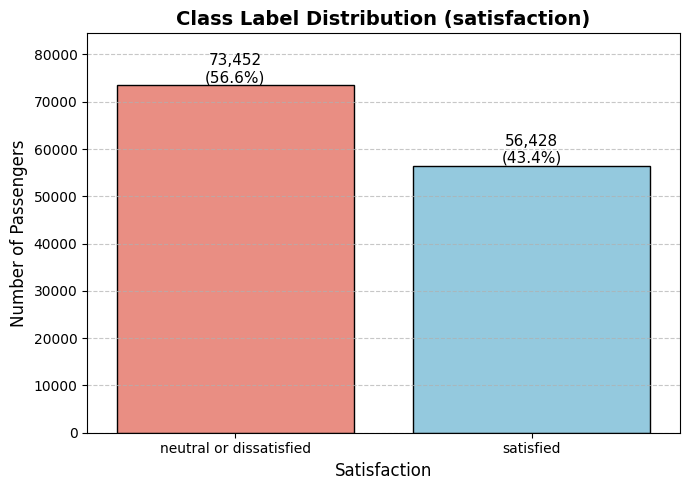

In [4]:
class_counts = df['satisfaction'].value_counts()
class_percent = df['satisfaction'].value_counts(normalize=True) * 100

print("Number of classes:", df['satisfaction'].nunique())
print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_percent.round(2)}))

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='satisfaction', data=df, order=class_counts.index,
                   hue='satisfaction', palette=['salmon', 'skyblue'], legend=False, edgecolor='black')

for p, pct in zip(ax.patches, class_percent[class_counts.index]):
    ax.annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Class Label Distribution (satisfaction)', fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.ylim(0, class_counts.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The class label `satisfaction` has two classes: **neutral or dissatisfied** with 73,452 passengers (56.6%) and **satisfied** with 56,428 passengers (43.4%).

The dataset is slightly imbalanced toward the "neutral or dissatisfied" class, but the difference (about 57% vs 43%) is not severe, and both classes contain a large number of records. This is consistent with the reference paper, which used a sample of the same dataset with a similar ratio (58.4% vs 41.6%) and considered it balanced. Therefore, we do not need resampling techniques such as oversampling or undersampling. However, when splitting the data into training and testing sets in Phase 3, we should use a **stratified split** so that every partition keeps the same class ratio.

## 5. Outlier Detection (IQR Method)

The boxplots above show outliers visually. Here we count them using the IQR rule: a value is an outlier if it is below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.

In [5]:
outlier_rows = []
for col in main_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({'Attribute': col, 'Min': df[col].min(), 'Q1': Q1, 'Median': df[col].median(),
                         'Q3': Q3, 'Max': df[col].max(), 'IQR': IQR,
                         'Lower Bound': lower, 'Upper Bound': upper,
                         'Outliers': n_out, 'Outliers (%)': round(n_out / len(df) * 100, 2)})

outlier_table = pd.DataFrame(outlier_rows).set_index('Attribute')
outlier_table

,Min,Q1,Median,Q3,Max,IQR,Lower Bound,Upper Bound,Outliers,Outliers (%)
Attribute,,,,,,,,,,
Age,7.0,27.0,40.0,51.0,85.0,24.0,-9.0,87.0,0,0.00
Flight Distance,31.0,414.0,844.0,1744.0,4983.0,1330.0,-1581.0,3739.0,2855,2.20
Departure Delay in Minutes,0.0,0.0,0.0,12.0,1592.0,12.0,-18.0,30.0,18098,13.93
Arrival Delay in Minutes,0.0,0.0,0.0,13.0,1584.0,13.0,-19.5,32.5,17492,13.47


The table shows the five-number summary (Min, Q1, Median, Q3, Max) together with the IQR bounds and the number of outliers for each numeric attribute:

- **Age:** 0 outliers. All ages (7 to 85) fall inside the IQR bounds, so no treatment is needed.
- **Flight Distance:** 2,855 outliers (2.2%), all above 3,739 miles. These are mostly real long-haul flights, so deleting all of them would lose useful data. However, the wide range (31 to 4,983) means this attribute needs **normalization** so it does not dominate the other attributes.
- **Departure Delay in Minutes:** 18,098 outliers (13.9%), all above 30 minutes.
- **Arrival Delay in Minutes:** 17,492 outliers (13.5%), all above 32.5 minutes.

The delay attributes have a very high share of outliers because most flights have no delay, which makes the IQR very small. Many of these delays are genuine events that may affect satisfaction, so deleting all IQR outliers (about 27% of the data) would lose too much information. Therefore, in preprocessing we used a less strict method (Z-score) that removes only the most extreme values.

## 6. Histograms (Distribution of Numeric Attributes)

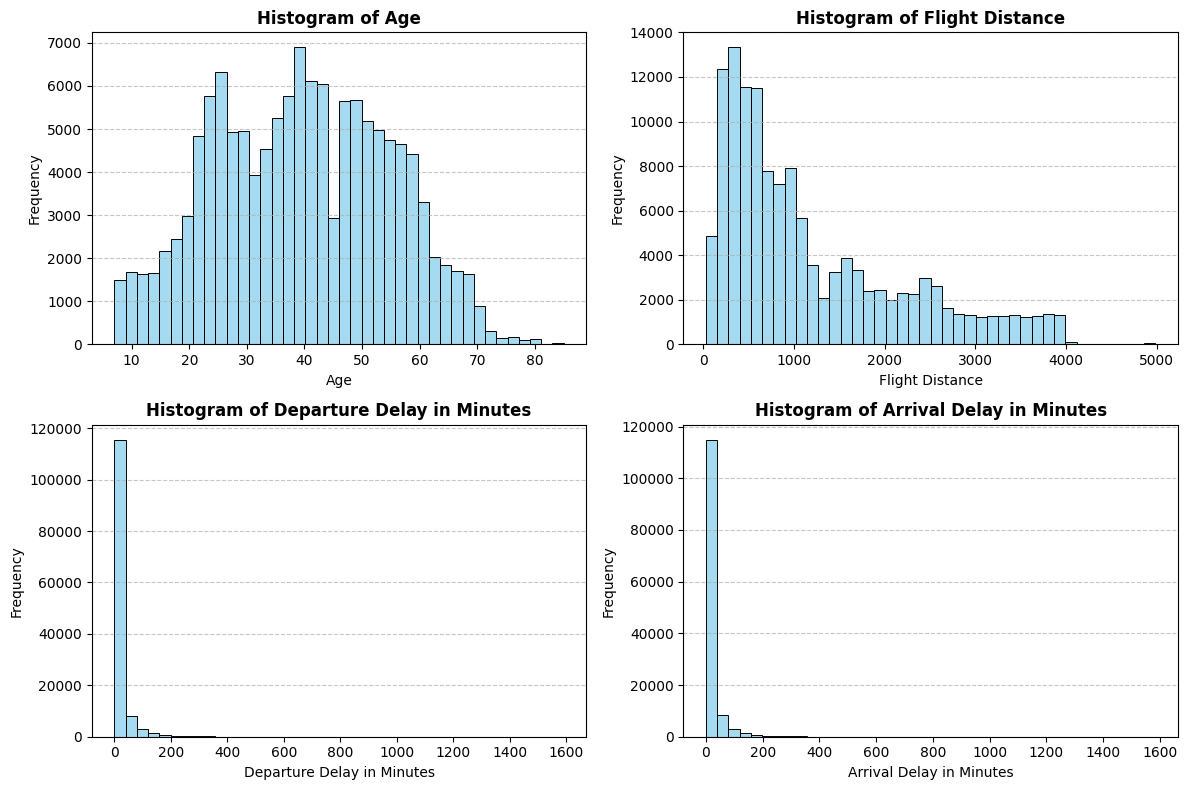

Skewness:
Age                          -0.00
Flight Distance               1.11
Departure Delay in Minutes    6.82
Arrival Delay in Minutes      6.67
dtype: float64


In [6]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(main_numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), bins=40, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Skewness:")
print(df[main_numeric_cols].skew().round(2))

The histograms show how the values of each numeric attribute are distributed:

- **Age:** Roughly symmetric (skewness ≈ 0), with about 83% of passengers between 20 and 60 years old. It does not need transformation, but it could be **discretized** into age groups to make it easier to interpret.
- **Flight Distance:** Right-skewed (skewness ≈ 1.1). About 79% of flights are shorter than 2,000 miles, and fewer flights are long-haul.
- **Departure Delay and Arrival Delay:** Extremely right-skewed (skewness ≈ 6.8 and 6.7). About 56% of flights have a delay of 0 minutes, and the frequency drops sharply as the delay increases.

**How this helps preprocessing:** The attributes are on very different scales (Age up to 85, Flight Distance up to about 5,000, delays up to about 1,600), so **normalization** (such as Min-Max scaling) is needed before clustering with K-means, which is based on distance. The strong skew in the delay attributes also shows that extreme values must be handled before normalization.


## 7. Bar Plots (Nominal Attributes vs. Satisfaction)

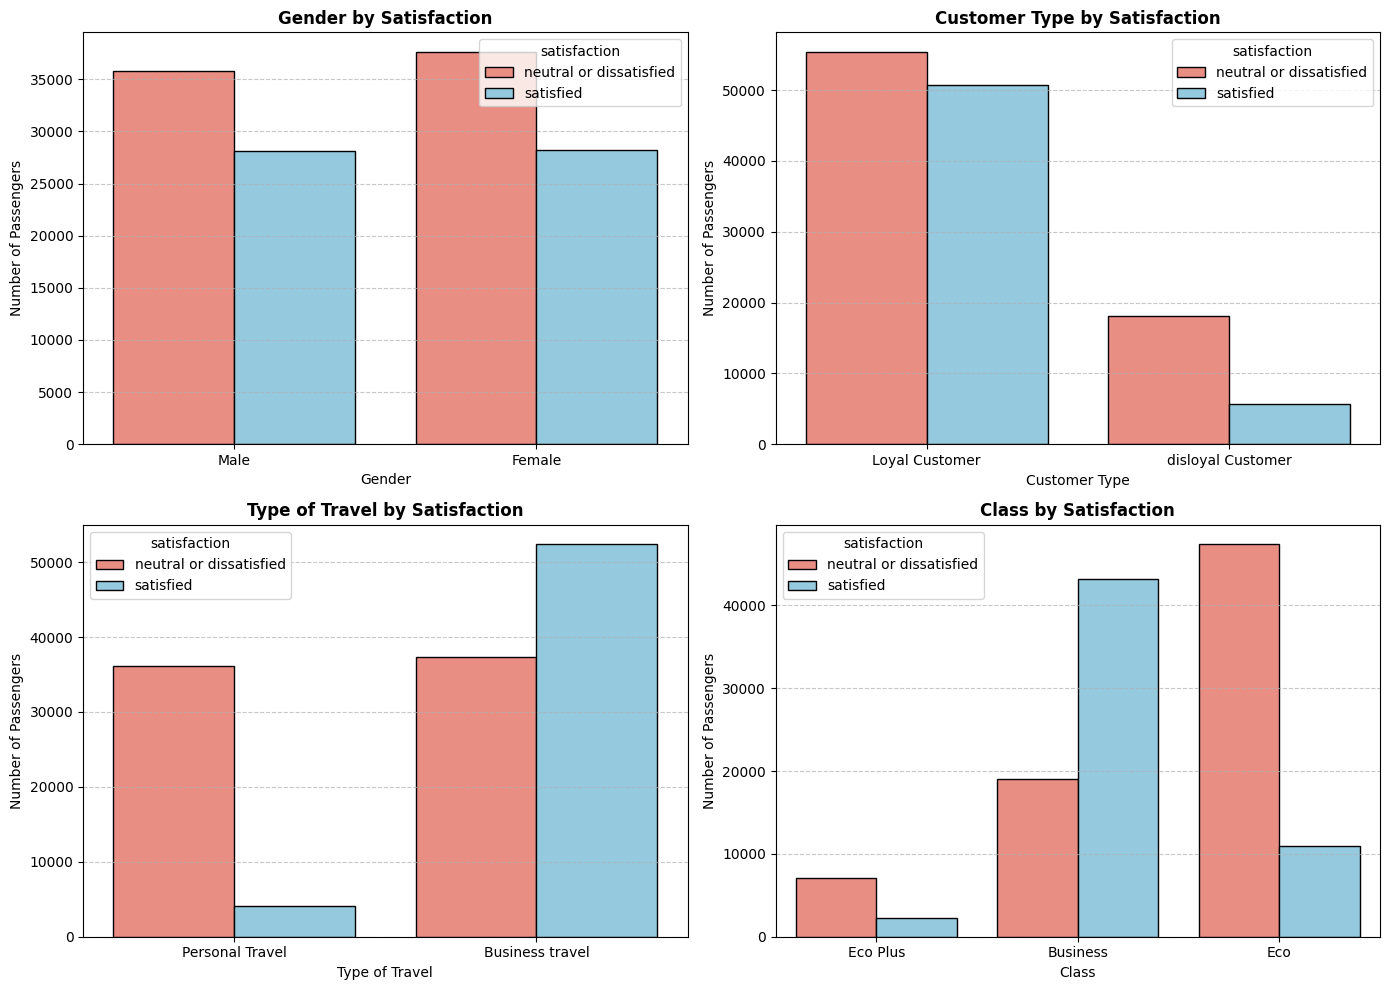


--- Gender: % satisfied in each category ---
Gender
Female    42.9
Male      44.0
Name: satisfied, dtype: float64

--- Customer Type: % satisfied in each category ---
Customer Type
Loyal Customer       47.8
disloyal Customer    24.0
Name: satisfied, dtype: float64

--- Type of Travel: % satisfied in each category ---
Type of Travel
Business travel    58.4
Personal Travel    10.1
Name: satisfied, dtype: float64

--- Class: % satisfied in each category ---
Class
Business    69.4
Eco         18.8
Eco Plus    24.6
Name: satisfied, dtype: float64


In [7]:
nominal_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

plt.figure(figsize=(14, 10))
for i, col in enumerate(nominal_cols, 1):
    plt.subplot(2, 2, i)
    ax = sns.countplot(x=col, hue='satisfaction', data=df, palette=['salmon', 'skyblue'], edgecolor='black')
    plt.title(f'{col} by Satisfaction', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Number of Passengers')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

for col in nominal_cols:
    print(f'\n--- {col}: % satisfied in each category ---')
    print((pd.crosstab(df[col], df['satisfaction'], normalize='index')['satisfied'] * 100).round(1))

The bar plots show the count of satisfied and neutral/dissatisfied passengers for each value of the nominal attributes:

- **Gender:** Female and male passengers have almost the same satisfaction rate (42.9% vs 44.0%). Gender has little effect on satisfaction, which is consistent with the reference paper, so it is a candidate to be dropped during **feature selection**.
- **Customer Type:** Loyal customers are satisfied 47.8% of the time, while disloyal customers are satisfied only 24.0% of the time.
- **Type of Travel:** This attribute shows the strongest difference. 58.4% of business travelers are satisfied, compared with only 10.1% of personal travelers.
- **Class:** Business class passengers are the most satisfied (69.4%), while Eco (18.8%) and Eco Plus (24.6%) passengers are mostly neutral or dissatisfied.

**How this helps preprocessing:** These four attributes are stored as text, so they must be converted to numbers (**encoding**, for example label or one-hot encoding) before they can be used by the decision tree and K-means. The plots also show that Customer Type, Type of Travel and Class are strongly related to the class label, so they should be kept, while Gender adds little information.

## 8. Scatter Plot (Departure Delay vs. Arrival Delay)

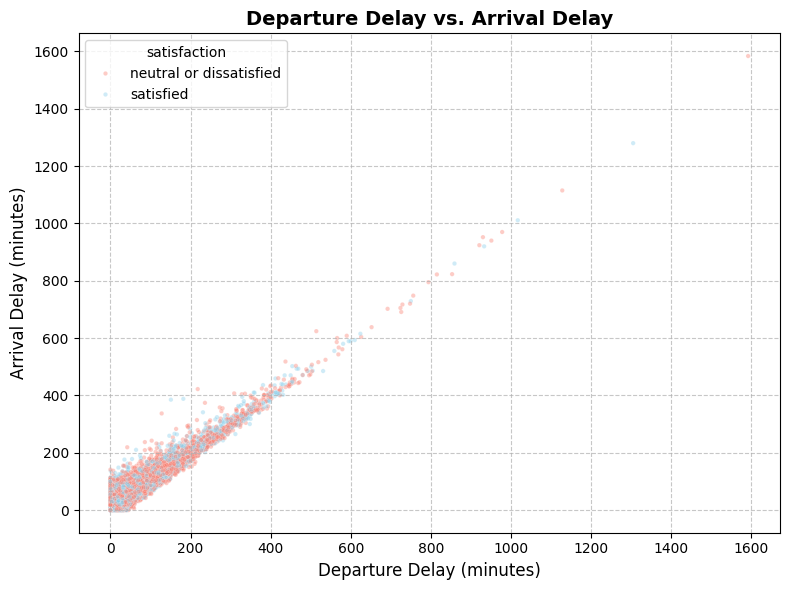

Correlation between Departure Delay and Arrival Delay: 0.965


In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Departure Delay in Minutes', y='Arrival Delay in Minutes', hue='satisfaction',
                data=df, palette=['salmon', 'skyblue'], alpha=0.4, s=10)

plt.title('Departure Delay vs. Arrival Delay', fontsize=14, fontweight='bold')
plt.xlabel('Departure Delay (minutes)', fontsize=12)
plt.ylabel('Arrival Delay (minutes)', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

corr = df['Departure Delay in Minutes'].corr(df['Arrival Delay in Minutes'])
print(f'Correlation between Departure Delay and Arrival Delay: {corr:.3f}')

The scatter plot shows a very strong positive linear relationship between departure delay and arrival delay: the points form an almost straight diagonal line, and the correlation coefficient is **0.965**. This makes sense, because a flight that leaves late usually arrives late by a similar amount of time.

**How this helps preprocessing:**
- Because the two attributes carry almost the same information, they are **redundant**. During **feature selection**, one of them (for example, Arrival Delay, which also has 393 missing values) can be removed.
- The 393 missing values in Arrival Delay are a small share (0.3%), and since the delay data is highly skewed, they can be filled with the median.
- Satisfied and dissatisfied passengers are mixed along the whole line, so delay alone cannot separate the two classes. The service rating attributes will be more important for classification.

# **Data Preprocessing**


## 1. Raw Dataset

In [9]:

df = pd.read_csv('https://github.com/Layal06-gh/IT326-Airline-Satisfaction/raw/refs/heads/main/Dataset/Raw_dataset.csv')
print(df.head())
print(df.info())
print(df.describe())

   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...                       1   
2                

##2. Handling Missing Value

In [10]:
from sklearn.impute import SimpleImputer
df_cleaned = df.copy()
df_cleaned = df_cleaned.drop(columns=['Unnamed: 0', 'id'])

print("Missing Values Before", df_cleaned['Arrival Delay in Minutes'].isnull().sum())
print("Rows before", len(df_cleaned))

imputer = SimpleImputer(strategy='median')
df_cleaned['Arrival Delay in Minutes'] = imputer.fit_transform(df_cleaned[['Arrival Delay in Minutes']])
print("Missing Values After" , df_cleaned['Arrival Delay in Minutes'].isnull().sum())
print("Rows after", len(df_cleaned))

Missing Values Before 393
Rows before 129880
Missing Values After 0
Rows after 129880


The missing values plot in the Data Analysis section shows that only
`Arrival Delay in Minutes` has missing values (393 rows, about 0.3% of the data).
Most algorithms cannot
handle NaN values, so they must be treated.
We replaced the missing values (imputation) using `SimpleImputer` from
scikit-learn with the **median** strategy. The median was chosen instead of the
mean because the mean would be pulled up by extreme values (the delay data is highly skewed)
Replacing instead of deleting keeps all rows of the dataset.

## 3. Outliner Removal

In [11]:
from scipy.stats import zscore

outlier_cols = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in outlier_cols:
    z_scores = zscore(df_cleaned[col])
    threshold = 3

    n_out = (abs(z_scores) > threshold).sum()
    print(f"{col}: {n_out} outliers (|z| > {threshold})")


    df_cleaned = df_cleaned[abs(zscore(df_cleaned[col])) <= threshold]

print("Rows after:", len(df_cleaned))

Flight Distance: 78 outliers (|z| > 3)
Departure Delay in Minutes: 2748 outliers (|z| > 3)
Arrival Delay in Minutes: 3744 outliers (|z| > 3)
Rows after: 123310


### Outlier Handling (Z-score method)
Flight Distance, Departure Delay, and Arrival Delay contain values far
from the typical range (most delays are near 0, but a few exceed 1,500
minutes). Using the Z-score method we flagged values more than 3 standard deviations from the mean as outliers.

Calculated Z-scores using `scipy.stats.zscore()` for each of the three continuous attributes, and removed rows where |z| > 3.

**Result:** 6570 Rows dropped. This keeps the vast majority of the data while removing extreme values that could distort scaling and clustering.

##4. Discretization

In [12]:
bins   = [0, 17, 30, 45, 60, 85]
labels = ['Child', 'Young Adult', 'Adult', 'Middle-aged', 'Senior']

df_cleaned['Age Group'] = pd.cut(df_cleaned['Age'], bins=bins, labels=labels)

print("Age groups:")
display(df_cleaned[['Age', 'Age Group']].head())
print(df_cleaned['Age Group'].value_counts().sort_index())

df_cleaned['Age Group'] = df_cleaned['Age Group'].cat.codes
df_cleaned = df_cleaned.drop(columns=['Age'])

Age groups:


,Age,Age Group
0,13,Child
1,25,Young Adult
2,26,Young Adult
3,25,Young Adult
4,61,Senior


Age Group
Child           9327
Young Adult    29450
Adult          39333
Middle-aged    35650
Senior          9550
Name: count, dtype: int64


We grouped Age into five ordered categories (Child, Young Adult, Adult, Middle-aged, Senior), encoded them as 0–4, and dropped the original column. Age has no outliers, but grouping it makes the decision tree rules easier to interpret. Result: Adult is the largest group (39,333) and Child the smallest (9,327).

## 5. Encoding

In [13]:
nominal_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

print("Before Encoding:")
display(df_cleaned[nominal_cols].head())

df_cleaned['Gender']         = df_cleaned['Gender'].map({'Female': 0, 'Male': 1})
df_cleaned['Customer Type']  = df_cleaned['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
df_cleaned['Type of Travel'] = df_cleaned['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
df_cleaned['Class']          = df_cleaned['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})
df_cleaned['satisfaction']   = df_cleaned['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

print("After Encoding:")
display(df_cleaned[nominal_cols].head())

Before Encoding:


,Gender,Customer Type,Type of Travel,Class,satisfaction
0,Male,Loyal Customer,Personal Travel,Eco Plus,neutral or dissatisfied
1,Male,disloyal Customer,Business travel,Business,neutral or dissatisfied
2,Female,Loyal Customer,Business travel,Business,satisfied
3,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
4,Male,Loyal Customer,Business travel,Business,satisfied


After Encoding:


,Gender,Customer Type,Type of Travel,Class,satisfaction
0,1,1,0,1,0
1,1,0,1,2,0
2,0,1,1,2,1
3,0,1,1,2,0
4,1,1,1,2,1


We converted the five text attributes to numbers: Gender, Customer Type, Type of Travel and satisfaction to 0/1, and Class to 0/1/2 (Eco, Eco Plus, Business) to keep its order. The decision tree and K-means cannot work with text. Result: All attributes are now numeric.

## 6. Normalization

In [14]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = df_cleaned.columns.drop('satisfaction')

print("Before Normalization:")
display(df_cleaned[feature_cols].head())

scaler = MinMaxScaler()
df_cleaned[feature_cols] = scaler.fit_transform(df_cleaned[feature_cols])

print("After Normalization:")
display(df_cleaned[feature_cols].head())

Before Normalization:


,Gender,Customer Type,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Age Group
0,1,1,0,1,460,3,4,3,1,5,...,5,4,3,4,4,5,5,25,18.0,0
1,1,0,1,2,235,3,2,3,3,1,...,1,1,5,3,1,4,1,1,6.0,1
2,0,1,1,2,1142,2,2,2,2,5,...,5,4,3,4,4,4,5,0,0.0,1
3,0,1,1,2,562,2,5,5,5,2,...,2,2,5,3,1,4,2,11,9.0,1
4,1,1,1,2,214,3,3,3,3,4,...,3,3,4,4,3,3,3,0,0.0,4


After Normalization:


,Gender,Customer Type,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Age Group
0,1.0,1.0,0.0,0.5,0.108088,0.6,0.8,0.6,0.2,1.0,...,1.0,0.8,0.6,0.75,0.75,1.0,1.0,0.196850,0.230769,0.00
1,1.0,0.0,1.0,1.0,0.051398,0.6,0.4,0.6,0.6,0.2,...,0.2,0.2,1.0,0.50,0.00,0.8,0.2,0.007874,0.076923,0.25
2,0.0,1.0,1.0,1.0,0.279919,0.4,0.4,0.4,0.4,1.0,...,1.0,0.8,0.6,0.75,0.75,0.8,1.0,0.000000,0.000000,0.25
3,0.0,1.0,1.0,1.0,0.133787,0.4,1.0,1.0,1.0,0.4,...,0.4,0.4,1.0,0.50,0.00,0.8,0.4,0.086614,0.115385,0.25
4,1.0,1.0,1.0,1.0,0.046107,0.6,0.6,0.6,0.6,0.8,...,0.6,0.6,0.8,0.75,0.50,0.6,0.6,0.000000,0.000000,1.00


We applied Min-Max normalization to all 22 attributes except satisfaction, scaling them to 0–1. The attributes had very different ranges (Flight Distance up to ~4,000, ratings 0–5), so larger attributes would dominate the distance in K-means. It was applied after outlier removal, since outliers would squeeze most values near 0. Result: All attributes contribute equally.

## 7. Preprocessed Dataset:


In [15]:
print("Final shape:", df_cleaned.shape)
display(df_cleaned.head())

df_cleaned.to_csv('Preprocessed_dataset.csv', index=False)

Final shape: (123310, 23)


,Gender,Customer Type,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Age Group
0,1.0,1.0,0.0,0.5,0.108088,0.6,0.8,0.6,0.2,1.0,...,0.8,0.6,0.75,0.75,1.0,1.0,0.196850,0.230769,0,0.00
1,1.0,0.0,1.0,1.0,0.051398,0.6,0.4,0.6,0.6,0.2,...,0.2,1.0,0.50,0.00,0.8,0.2,0.007874,0.076923,0,0.25
2,0.0,1.0,1.0,1.0,0.279919,0.4,0.4,0.4,0.4,1.0,...,0.8,0.6,0.75,0.75,0.8,1.0,0.000000,0.000000,1,0.25
3,0.0,1.0,1.0,1.0,0.133787,0.4,1.0,1.0,1.0,0.4,...,0.4,1.0,0.50,0.00,0.8,0.4,0.086614,0.115385,0,0.25
4,1.0,1.0,1.0,1.0,0.046107,0.6,0.6,0.6,0.6,0.8,...,0.6,0.8,0.75,0.50,0.6,0.6,0.000000,0.000000,1,1.00


The final dataset has 123,310 rows and 23 attributes, with no missing values and all values numeric, ready for Phase 3. It was saved as Preprocessed_dataset.csv.